<a href="https://colab.research.google.com/github/ernesto10loera-star/Actividades-IAyRN/blob/main/AF7_RNP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Datos de entrenamiento cargados: (60000, 28, 28)
Datos de prueba cargados: (10000, 28, 28)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



--- Iniciando entrenamiento del modelo ---
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9267 - loss: 0.2588
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9657 - loss: 0.1164
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9755 - loss: 0.0794
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9815 - loss: 0.0602
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9866 - loss: 0.0454

--- Evaluación del modelo con el conjunto de prueba ---
313/313 - 1s - 2ms/step - accuracy: 0.9770 - loss: 0.0717

Exactitud de la predicción (Accuracy): 0.9770

--- Realizando 5 predicciones individuales ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Ejemplo 1: Predicción -> 0 | Valor Real -> 0
Ejemplo 2: Predicción -> 6 | Valor Real -> 6
Ejemplo 3: Predicción -> 9 | Valor Real -> 9
Ejemplo 4: Predicción -> 0 | Valor Real -> 0
Ejemplo 5: Predicción -> 1 | Valor Real -> 1


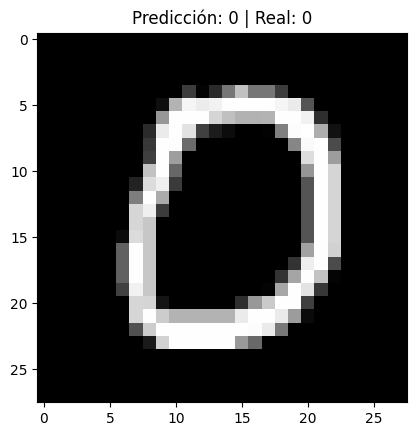

In [1]:
#AF7: Redes Neuronales Artificiales, Ernesto Gerardo Loera Vega 2101664 V6

# 1. Cargar librerías

import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt


# 2. Cargar datos (Punto: Uso de load_data y nombres de variables)

# Cargamos el dataset MNIST directamente desde Keras
(train_data, train_labels), (test_data, test_labels) = keras.datasets.mnist.load_data()

print(f"Datos de entrenamiento cargados: {train_data.shape}")
print(f"Datos de prueba cargados: {test_data.shape}")


# 3. Preprocesamiento de datos

# Normalización: Convertir píxeles de 0-255 a un rango de 0-1
train_data = train_data / 255.0
test_data = test_data / 255.0


# 4. Selección y entrenamiento del modelo (Arquitectura Feedforward)

# Proponemos una estructura de Red Neuronal Artificial Prealimentada
modelo = keras.Sequential([
    # Capa de entrada: Aplana la imagen de 28x28 a un vector de 784
    keras.layers.Flatten(input_shape=(28, 28)),

    # Capa oculta: 128 neuronas con función de activación ReLU
    keras.layers.Dense(128, activation='relu'),

    # Capa de salida: 10 neuronas (una por dígito) con activación SOFTMAX
    keras.layers.Dense(10, activation='softmax')
])

# Establecer tipo de función de pérdida, optimizador y métrica
modelo.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenamiento del modelo usando la función "fit"
print("\n--- Iniciando entrenamiento del modelo ---")
modelo.fit(train_data, train_labels, epochs=5)


# 5. Prueba del modelo (Punto: Función evaluate)

print("\n--- Evaluación del modelo con el conjunto de prueba ---")
# Evaluamos la exactitud (accuracy) del modelo
test_loss, test_acc = modelo.evaluate(test_data, test_labels, verbose=2)
print(f'\nExactitud de la predicción (Accuracy): {test_acc:.4f}')


# 6. Realizar 5 predicciones diferentes

print("\n--- Realizando 5 predicciones individuales ---")
# Obtenemos las predicciones para el conjunto de prueba
predicciones_prob = modelo.predict(test_data)

# Mostramos 5 ejemplos seleccionados (del índice 10 al 14)
for i in range(10, 15):
    # La predicción es el índice con la probabilidad más alta (argmax)
    prediccion_final = np.argmax(predicciones_prob[i])
    valor_real = test_labels[i]

    print(f"Ejemplo {i-9}: Predicción -> {prediccion_final} | Valor Real -> {valor_real}")

# Opcional: Visualizar uno de los ejemplos predichos
plt.imshow(test_data[10], cmap='gray')
plt.title(f"Predicción: {np.argmax(predicciones_prob[10])} | Real: {test_labels[10]}")
plt.show()